In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)
else:
    print("CUDA GPU not detected")

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
CUDA: 13.0


In [5]:
image_size = 64
batch_size = 128
latent_dim = 100
num_epochs = 5
learning_rate = 1e-3

print("Using:", device)


Using: cuda


In [10]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

In [11]:
dataset = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=transform
)

print("Dataset downloaded successfully!")

100%|██████████| 170M/170M [40:29<00:00, 70.2kB/s]   


Dataset downloaded successfully!


In [12]:
dataset = Subset(dataset, range(500))

dataloader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)

print("Number of images:", len(dataset))
print("Number of batches:", len(dataloader))

Number of images: 500
Number of batches: 4


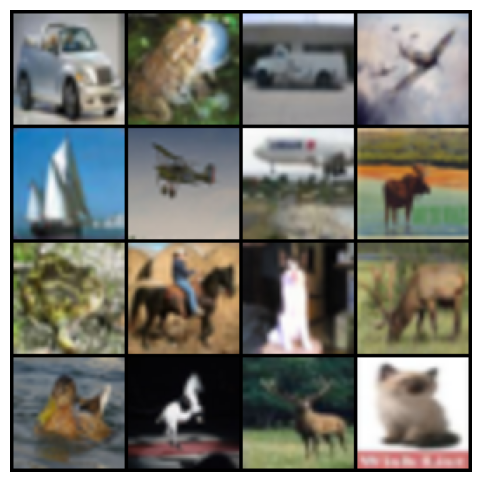

In [13]:
images, _ = next(iter(dataloader))

grid = torchvision.utils.make_grid(
    images[:16] * 0.5 + 0.5,
    nrow=4
)

plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()